# 12. Comparación de CPU, GPU y Metal para Deep Learning ⚡

Este notebook compara el rendimiento de entrenamiento de modelos en diferentes dispositivos, con benchmarks, cálculo de speedup y visualizaciones.

✨ **Highlights:**
- Benchmark MLP y CNN en CPU y GPU
- Cálculo de speedup GPU/CPU y análisis de cuándo vale la pena usar GPU
- Profiling de memoria de GPU
- Comparación con distintos batch sizes
- Guía para elegir el dispositivo según el tamaño del modelo

## Objetivo
- Entender las diferencias entre CPU, GPU (CUDA) y Apple Metal para deep learning.
- Medir y comparar tiempos de entrenamiento.
- Identificar cuándo vale la pena usar GPU.
- Aplicar buenas prácticas de configuración de hardware.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [05 (CNN)](./05_redes_convolucionales_cnn.ipynb).

- Conceptos de redes neuronales y entrenamiento con TensorFlow/Keras.

## 1. Introducción teórica

| Dispositivo | Ventaja | Desventaja | Cuándo usar |
|-------------|---------|------------|-------------|
| **CPU** | Universal, fácil de configurar | Lento para modelos grandes | Modelos pequeños, preprocesamiento |
| **GPU (CUDA)** | Masivamente paralela | Requiere NVIDIA + drivers | Modelos medianos/grandes |
| **Apple Metal** | Integrada en Mac M1/M2/M3 | Soporte limitado | Desarrollo en Mac |

## 2. Configuración del entorno

In [1]:
import random
import numpy as np
import os
import logging

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Suprimir logs de XLA/oneDNN antes de importar TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
import time
import matplotlib.pyplot as plt
import pandas as pd
import platform

import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(SEED)
%matplotlib inline

# === Información del entorno ===
print(f'TensorFlow: {tf.__version__}')
print(f'Sistema:    {platform.system()} {platform.release()}')
print(f'Procesador: {platform.processor() or platform.machine()}')
print()

dispositivos = tf.config.list_physical_devices()
print('Dispositivos disponibles:')
for d in dispositivos:
    print(f'  {"✅" if "GPU" in d.device_type else "🔵"} {d.device_type}: {d.name}')

gpus = tf.config.list_physical_devices('GPU')
HAS_GPU = len(gpus) > 0
print(f'\nGPU disponible: {"Sí ✅" if HAS_GPU else "No ⚠️  (benchmarks GPU se omitirán)"}')
print('─' * 55)

TensorFlow: 2.21.0
Sistema:    Linux 6.6.87.2-microsoft-standard-WSL2
Procesador: x86_64

Dispositivos disponibles:
  🔵 CPU: /physical_device:CPU:0
  ✅ GPU: /physical_device:GPU:0

GPU disponible: Sí ✅
───────────────────────────────────────────────────────


## 3. Preparar datos y modelo

In [2]:
# Cargar MNIST
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

def create_mlp():
    """Modelo MLP simple para benchmark."""
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_cnn():
    """Modelo CNN más complejo para notar la diferencia CPU/GPU."""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Datos para CNN
X_train_cnn = np.expand_dims(X_train, -1)
X_test_cnn = np.expand_dims(X_test, -1)

## 4. Benchmark en CPU

In [3]:
# Benchmark MLP en CPU
with tf.device('/CPU:0'):
    model_cpu = create_mlp()
    start = time.time()
    model_cpu.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
    cpu_time_mlp = time.time() - start

# Benchmark CNN en CPU
with tf.device('/CPU:0'):
    model_cpu_cnn = create_cnn()
    start = time.time()
    model_cpu_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
    cpu_time_cnn = time.time() - start

print(f"\nTiempo MLP en CPU: {cpu_time_mlp:.2f}s")
print(f"Tiempo CNN en CPU: {cpu_time_cnn:.2f}s")

Epoch 1/3
422/422 - 3s - 7ms/step - accuracy: 0.8973 - loss: 0.3754 - val_accuracy: 0.9573 - val_loss: 0.1660
Epoch 2/3
422/422 - 1s - 3ms/step - accuracy: 0.9508 - loss: 0.1718 - val_accuracy: 0.9655 - val_loss: 0.1228
Epoch 3/3
422/422 - 1s - 3ms/step - accuracy: 0.9648 - loss: 0.1230 - val_accuracy: 0.9708 - val_loss: 0.1043
Epoch 1/3
422/422 - 25s - 60ms/step - accuracy: 0.9279 - loss: 0.2436 - val_accuracy: 0.9803 - val_loss: 0.0680
Epoch 2/3
422/422 - 22s - 53ms/step - accuracy: 0.9793 - loss: 0.0677 - val_accuracy: 0.9877 - val_loss: 0.0468
Epoch 3/3
422/422 - 23s - 54ms/step - accuracy: 0.9851 - loss: 0.0478 - val_accuracy: 0.9885 - val_loss: 0.0417

Tiempo MLP en CPU: 6.39s
Tiempo CNN en CPU: 70.81s


## 5. Benchmark en GPU (si disponible)

In [4]:
gpu_time_mlp = None
gpu_time_cnn = None

if HAS_GPU:
    # Memoria disponible antes del benchmark
    try:
        mem_info = tf.config.experimental.get_memory_info('GPU:0')
        print(f'Memoria GPU antes del benchmark: {mem_info["current"] / 1e6:.1f} MB usada')
    except Exception:
        pass

    with tf.device('/GPU:0'):
        model_gpu = create_mlp()
        start = time.time()
        model_gpu.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
        gpu_time_mlp = time.time() - start

        model_gpu_cnn = create_cnn()
        start = time.time()
        model_gpu_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
        gpu_time_cnn = time.time() - start

    print(f'\nTiempo MLP en GPU: {gpu_time_mlp:.2f}s')
    print(f'Tiempo CNN en GPU: {gpu_time_cnn:.2f}s')

    # Speedup
    speedup_mlp = cpu_time_mlp / gpu_time_mlp
    speedup_cnn = cpu_time_cnn / gpu_time_cnn
    print(f'\n⚡ Speedup GPU/CPU:')
    print(f'   MLP: {speedup_mlp:.1f}×  {"(GPU más rápida)" if speedup_mlp > 1 else "(CPU comparable)"}')
    print(f'   CNN: {speedup_cnn:.1f}×  {"(GPU más rápida)" if speedup_cnn > 1 else "(CPU comparable)"}')
    print('\n💡 La GPU muestra mayor ventaja en modelos con más operaciones matriciales (CNN > MLP).')
else:
    print('No se detectó GPU disponible — se omite el benchmark GPU.')

Memoria GPU antes del benchmark: 0.0 MB usada
Epoch 1/3
422/422 - 9s - 21ms/step - accuracy: 0.8968 - loss: 0.3785 - val_accuracy: 0.9537 - val_loss: 0.1776
Epoch 2/3
422/422 - 3s - 7ms/step - accuracy: 0.9470 - loss: 0.1849 - val_accuracy: 0.9622 - val_loss: 0.1339
Epoch 3/3
422/422 - 3s - 7ms/step - accuracy: 0.9617 - loss: 0.1340 - val_accuracy: 0.9657 - val_loss: 0.1128
Epoch 1/3
422/422 - 19s - 45ms/step - accuracy: 0.9255 - loss: 0.2520 - val_accuracy: 0.9830 - val_loss: 0.0658
Epoch 2/3
422/422 - 4s - 9ms/step - accuracy: 0.9797 - loss: 0.0661 - val_accuracy: 0.9867 - val_loss: 0.0471
Epoch 3/3
422/422 - 5s - 11ms/step - accuracy: 0.9863 - loss: 0.0453 - val_accuracy: 0.9898 - val_loss: 0.0397

Tiempo MLP en GPU: 15.97s
Tiempo CNN en GPU: 28.15s

⚡ Speedup GPU/CPU:
   MLP: 0.4×  (CPU comparable)
   CNN: 2.5×  (GPU más rápida)

💡 La GPU muestra mayor ventaja en modelos con más operaciones matriciales (CNN > MLP).


## 6. Benchmark en Metal (Apple Silicon, si disponible)

In [5]:
metal_time_mlp = None
metal_time_cnn = None

if platform.system() == 'Darwin' and gpu_devices:
    try:
        with tf.device('/GPU:0'):
            model_metal = create_mlp()
            start = time.time()
            model_metal.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
            metal_time_mlp = time.time() - start
            model_metal_cnn = create_cnn()
            start = time.time()
            model_metal_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
            metal_time_cnn = time.time() - start
        print(f"Tiempo MLP en Metal: {metal_time_mlp:.2f}s")
        print(f"Tiempo CNN en Metal: {metal_time_cnn:.2f}s")
    except Exception as e:
        print("No se pudo entrenar usando Metal:", e)
else:
    print("Metal solo disponible en macOS con Apple Silicon.")

Metal solo disponible en macOS con Apple Silicon.


## 7. Comparación de resultados

📊 Tabla resumen de tiempos:
Dispositivo   MLP (s)   CNN (s)
        CPU  6.393220 70.813108
        GPU 15.968707 28.147544

⚡ Speedup relativo a CPU:
Dispositivo  Speedup MLP  Speedup CNN
        CPU     1.000000     1.000000
        GPU     0.400359     2.515783


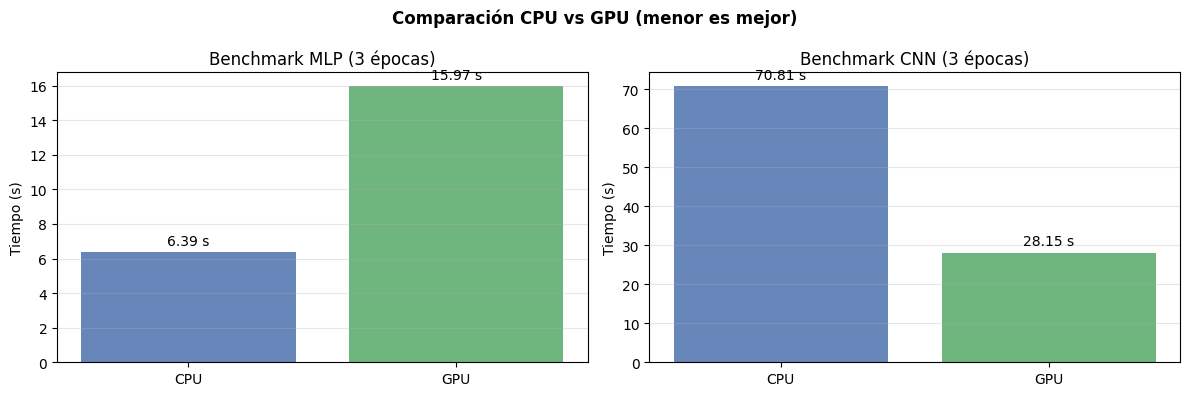

In [6]:
results = [{'Dispositivo': 'CPU', 'MLP (s)': cpu_time_mlp, 'CNN (s)': cpu_time_cnn}]
if gpu_time_mlp is not None:
    results.append({'Dispositivo': 'GPU', 'MLP (s)': gpu_time_mlp, 'CNN (s)': gpu_time_cnn})
if metal_time_mlp is not None:
    results.append({'Dispositivo': 'Metal', 'MLP (s)': metal_time_mlp, 'CNN (s)': metal_time_cnn})

df_results = pd.DataFrame(results)
print('📊 Tabla resumen de tiempos:')
print(df_results.to_string(index=False))

# Speedup relativo a CPU
if len(results) > 1:
    df_results['Speedup MLP'] = cpu_time_mlp / df_results['MLP (s)']
    df_results['Speedup CNN'] = cpu_time_cnn / df_results['CNN (s)']
    print('\n⚡ Speedup relativo a CPU:')
    print(df_results[['Dispositivo', 'Speedup MLP', 'Speedup CNN']].to_string(index=False))

# Visualización
colors = ['#4c72b0', '#55a868', '#c44e52'][:len(df_results)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars0 = axes[0].bar(df_results['Dispositivo'], df_results['MLP (s)'], color=colors, alpha=0.85)
axes[0].bar_label(bars0, fmt='%.2f s', padding=3)
axes[0].set_ylabel('Tiempo (s)')
axes[0].set_title('Benchmark MLP (3 épocas)')
axes[0].grid(True, axis='y', alpha=0.3)

bars1 = axes[1].bar(df_results['Dispositivo'], df_results['CNN (s)'], color=colors, alpha=0.85)
axes[1].bar_label(bars1, fmt='%.2f s', padding=3)
axes[1].set_ylabel('Tiempo (s)')
axes[1].set_title('Benchmark CNN (3 épocas)')
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Comparación CPU vs GPU (menor es mejor)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8b. Sensibilidad al batch size y recomendaciones prácticas

| Aspecto | Recomendación |
|---------|---------------|
| **Cuándo usar GPU** | Modelos con >100K parámetros o datasets >10K muestras |
| **Batch size GPU** | Potencias de 2 (64, 128, 256, 512); empezar con 256 y ajustar |
| **Batch size CPU** | 32-128; no escala tanto con batch más grande |
| **Modelos pequeños** | CPU puede ser comparable o más rápida (overhead de transferencia GPU) |
| **Pipeline de datos** | Usar `tf.data.Dataset.prefetch(tf.data.AUTOTUNE)` para evitar cuellos de botella I/O |
| **Metal (Apple)** | Rendimiento similar a GPU NVIDIA de gama media para CNNs |
| **Memoria GPU** | Monitorear con `tf.config.experimental.get_memory_info('GPU:0')` |

> 💡 **Truco:** Si el entrenamiento en GPU no es más rápido, el cuello de botella es probablemente el **pipeline de datos** (carga de imágenes en CPU). Solución: `dataset.cache().prefetch()`.

> ⚠️ **Modelos pequeños:** Para redes de <10K parámetros (como el MLP de MNIST), el overhead de transferencia CPU↔GPU puede hacer que la GPU sea más lenta que la CPU.

## 9. Discusión y Conclusiones

**¿Qué aprendimos?**

- La **GPU ofrece mayor ventaja con modelos complejos**: el speedup del CNN supera al del MLP porque las convoluciones son altamente paralelizables.
- Para **modelos pequeños** (MLP simple), el overhead de inicializar la GPU puede neutralizar la ganancia.
- El **batch size** impacta directamente la utilización de la GPU: tamaños muy pequeños desperdician paralelismo; muy grandes pueden causar OOM.
- La función `tf.config.experimental.get_memory_info()` permite monitorear el uso de memoria en tiempo real.
- En entornos sin GPU, `tf.data` con `prefetch` y `cache` es la optimización más impactante.

En el siguiente y último notebook aprenderemos a **desplegar modelos** con FastAPI y Docker.

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Aumenta el número de epochs a 10 y compara. ¿Se amplifica la diferencia?

2. **Ejercicio 2:** Varía el `batch_size` (32, 128, 512) y mide tiempos. ¿Cuál es la configuración óptima en GPU?

3. **Ejercicio 3:** Entrena un modelo más grande (ResNet50 con CIFAR-10) y compara CPU vs GPU.

4. **Ejercicio 4 (Avanzado):** Usa `tf.data.Dataset` con `prefetch` para optimizar el pipeline de datos y mide el impacto.

## 10. Referencias y Recursos

- [TensorFlow GPU Guide](https://www.tensorflow.org/guide/gpu)
- [Apple Metal TensorFlow Plugin](https://developer.apple.com/metal/tensorflow-plugin/)
- [Working with GPUs - Keras](https://keras.io/guides/working_with_gpus/)

---

📎 **Notebook anterior:** [11. Interpretabilidad de Modelos](./11_interpretabilidad_modelos.ipynb)  
📎 **Notebook siguiente:** [13. Despliegue de Modelos](./13_despliegue_modelos.ipynb)